<a href="https://colab.research.google.com/github/Noorulhuda-12/flyrank/blob/main/flyrank_eda_ipynb_txt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FlyRank EDA & Quick Ranking Demo

This notebook loads the starter CSV from the repo, finds date-like columns, fixes avg_position (0 → missing), runs a simple rule-based score, shows top items, and computes precision@K on a proxy label. Designed to run in Google Colab.

In [2]:
# Install small dependency and import libraries
!pip install pyarrow --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
from pathlib import Path
Path("work/outputs").mkdir(parents=True, exist_ok=True)

In [3]:
# Load the starter CSV from the GitHub repo (no parse_dates to avoid errors if column missing)
url = "https://raw.githubusercontent.com/Noorulhuda-12/flyrank/main/data/raw/content_refresh_anonymized.csv"
df = pd.read_csv(url, low_memory=False)
print('Loaded shape:', df.shape)


Loaded shape: (30000, 44)


In [4]:
# Quick checks: show shape, top missing columns
print("Rows, cols:", df.shape)
missing = (df.isna().mean().sort_values(ascending=False) * 100).round(2)
print("\nTop 10 columns by missing rate (percent):")
print(missing.head(10))


Rows, cols: (30000, 44)

Top 10 columns by missing rate (percent):
provider_used        71.46
word_count           25.66
char_count           25.66
word_count_tier      25.66
char_count_tier      25.66
model_used           19.11
trend_pct            11.29
competition_level     8.70
search_volume         8.23
cpc                   8.23
dtype: float64


In [5]:
# Find date-like candidate columns and show first values
cols = df.columns.tolist()
candidates = [c for c in cols if any(k in c.lower() for k in ['date','day','time','report'])]
print("Date-like candidate columns:", candidates)
for c in candidates:
    print('\nColumn:', c)
    print(df[c].head(10))


Date-like candidate columns: ['days_with_impressions', 'days_with_sessions', 'content_age_days', 'days_since_last_update']

Column: days_with_impressions
0    88
1    88
2    88
3    88
4    88
5    88
6    13
7    88
8    83
9    88
Name: days_with_impressions, dtype: int64

Column: days_with_sessions
0    13
1     9
2    11
3    51
4    33
5     5
6     1
7    11
8    44
9     3
Name: days_with_sessions, dtype: int64

Column: content_age_days
0    187
1    445
2    141
3    463
4    263
5    147
6     90
7    445
8     90
9    257
Name: content_age_days, dtype: int64

Column: days_since_last_update
0     20
1     25
2     20
3     22
4     14
5     20
6     20
7     22
8     20
9    104
Name: days_since_last_update, dtype: int64


In [6]:
# Fix avg_position special case: 0 means 'no data' -> convert to NaN
if 'avg_position' in df.columns:
    before = (df['avg_position'] == 0).sum()
    df.loc[df['avg_position'] == 0, 'avg_position'] = np.nan
    after_missing_pct = df['avg_position'].isna().mean() * 100
    print(f"Rows that were exactly 0 before: {before}")
    print(f"avg_position missing now: {after_missing_pct:.2f}%")
else:
    print('avg_position column not present in this CSV')


Rows that were exactly 0 before: 1205
avg_position missing now: 4.02%


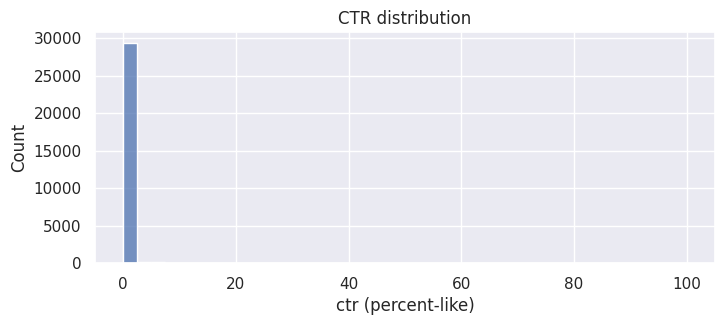

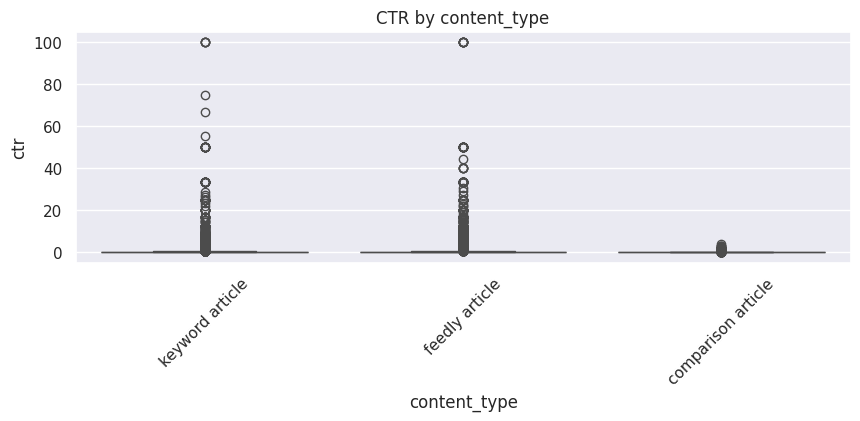

In [7]:
# Quick plots: CTR distribution and CTR by content_type
if 'ctr' in df.columns:
    plt.figure(figsize=(8,3))
    sns.histplot(df['ctr'].dropna(), bins=40)
    plt.title("CTR distribution")
    plt.xlabel("ctr (percent-like)")
    plt.show()
else:
    print('ctr column not found')

if 'content_type' in df.columns and 'ctr' in df.columns:
    plt.figure(figsize=(10,3))
    sns.boxplot(x='content_type', y='ctr', data=df.dropna(subset=['content_type','ctr']))
    plt.xticks(rotation=45)
    plt.title("CTR by content_type")
    plt.show()
else:
    print('content_type or ctr missing; skipping boxplot')


In [8]:
# Demo features + proxy label (fast; not time-aware)
df = df.copy()
if 'avg_position' in df.columns:
    df['avg_position'] = df['avg_position'].replace(0, np.nan)
df['has_keywords'] = df['keywords'].notna().astype(int) if 'keywords' in df.columns else 0
df['title_length'] = df['title'].fillna('').astype(str).str.split().apply(len) if 'title' in df.columns else 0
df['is_low_position'] = (df['avg_position'] > 10).fillna(False).astype(int) if 'avg_position' in df.columns else 0
df['is_low_wordcount'] = (df['word_count'].fillna(0) < 300).astype(int) if 'word_count' in df.columns else 0

if 'ctr' in df.columns and 'content_type' in df.columns:
    df['median_ctr_by_type'] = df.groupby('content_type')['ctr'].transform('median')
    df['low_ctr_label'] = (df['ctr'] < df['median_ctr_by_type']).astype(int)
else:
    # fallback: label missing
    df['low_ctr_label'] = 0

print('Rows:', len(df))
if 'low_ctr_label' in df.columns:
    print('Fraction low_ctr_label:', df['low_ctr_label'].mean())


Rows: 30000
Fraction low_ctr_label: 0.44913333333333333


In [9]:
# Rule-based score and show top items
df['score'] = 3*df.get('is_low_position', 0) + 2*df.get('low_ctr_label', 0) + 1*(1 - df.get('has_keywords', 0)) + 0.5*df.get('is_low_wordcount', 0)
smin = df['score'].min()
smax = df['score'].max()
df['score_norm'] = (df['score'] - smin) / (smax - smin) if smax != smin else 0

display_cols = [c for c in ['content_id','client_id','content_type','ctr','avg_position','has_keywords','title_length','score_norm'] if c in df.columns]
top = df.sort_values('score_norm', ascending=False).head(10)
display(top[display_cols].reset_index(drop=True))


,content_id,client_id,content_type,ctr,avg_position,has_keywords,title_length,score_norm
0,content_1df00efe44a1,client_e629fa6598,keyword article,0.00,20.7,0,0,1.0
1,content_249298388b45,client_2c624232cd,keyword article,0.00,50.4,0,0,1.0
2,content_18aca5eb5eef,client_19581e27de,keyword article,0.04,13.5,0,0,1.0
3,content_a63219c6e95a,client_19581e27de,keyword article,0.06,21.2,0,0,1.0
4,content_fe5d259e6bc5,client_19581e27de,keyword article,0.00,37.1,0,0,1.0
5,content_9bd30342fd4a,client_19581e27de,keyword article,0.00,33.1,0,0,1.0
6,content_ce52d62a83f9,client_19581e27de,keyword article,0.00,40.3,0,0,1.0
7,content_75549383e57c,client_19581e27de,keyword article,0.00,28.0,0,0,1.0
8,content_b17dd18b28df,client_19581e27de,keyword article,0.00,27.4,0,0,1.0
9,content_e6cc2aad65ea,client_19581e27de,keyword article,0.00,14.4,0,0,1.0


In [10]:
# Precision@K on the proxy label
def precision_at_k(df_sorted, label_col='low_ctr_label', k=10):
    topk = df_sorted.head(k)
    if label_col not in topk.columns:
        return None
    return topk[label_col].sum() / k

for k in [5,10,20,50]:
    p = precision_at_k(df.sort_values('score_norm', ascending=False), 'low_ctr_label', k)
    print(f"Precision@{k}: {p if p is not None else 'label missing'}")


Precision@5: 1.0
Precision@10: 1.0
Precision@20: 1.0
Precision@50: 1.0


In [11]:
# Save outputs: top10 CSV, small cache, and the frame text. If running in Colab, these will be available to download.
top.to_csv('top10_recommendations.csv', index=False)
try:
    import pyarrow
    cache_cols = [c for c in ['content_id','client_id','ctr','avg_position','content_type','word_count','score_norm'] if c in df.columns]
    df[cache_cols].to_parquet('eda_starter.parquet', index=False)
except Exception as e:
    print('Could not save parquet:', e)

frame = """For content editors deciding which pages to fix first, I will build a simple ranked score from FlyRank data to find pages likely to lose clicks or have low engagement. I will start with the starter CSV in this repo and validate results with a later time window from the warehouse sample. Success will be measured by precision@K and average CTR lift. A wrong call wastes editor hours, so results will be conservative and used as decision-support only. I will avoid any features that use future data (no leakage)."""
with open('frame.txt','w') as f:
    f.write(frame)

try:
    from google.colab import files
    files.download('top10_recommendations.csv')
    files.download('eda_starter.parquet')
    files.download('frame.txt')
except Exception:
    print('If you are not in Colab, files are saved in the notebook working directory.')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Step 1 — install and import (one cell) Paste & run:

In [ ]:
# Install and imports - run once
!pip install duckdb==0.8.1 pyarrow --quiet

import duckdb
import pandas as pd
import numpy as np
from getpass import getpass
from pathlib import Path
from datetime import datetime, timedelta

# create outputs dir
Path("work/outputs").mkdir(parents=True, exist_ok=True)
print("Initial setup done.")

Step 2 — provide your HF token securely and load httpfs (one cell) Paste & run, then type/paste your token when prompted:

In [ ]:
# Enter your HF token securely (you will type it in the prompt)
HF_TOKEN = getpass("Paste Hugging Face read token (it will not be saved to files): ")

# Load httpfs in DuckDB and set the Bearer token for HTTPFS access
duckdb.query("INSTALL httpfs;").fetchall()
duckdb.query("LOAD httpfs;").fetchall()
# Set the HTTPFS auth header for HuggingFace
duckdb.query(f"SET HTTPFS_AUTH_BEARER='{HF_TOKEN}';").fetchall()

print("httpfs loaded and token set (in-session only).")

Step 3 — run the aggregation and save a cached labelled file (one cell)

Default freeze date is 2026-05-01. Change freeze_date variable if you want another T.
This cell builds prev30 and next30 averages and writes work/outputs/labelled_agg.parquet. Paste & run:

In [ ]:
# Choose freeze date T (edit if you want another date)
freeze_date = '2026-05-01'

# compute window bounds in Python to avoid SQL date arithmetic variations
freeze = datetime.strptime(freeze_date, '%Y-%m-%d').date()
prev_start = (freeze - timedelta(days=30)).isoformat()
prev_end   = freeze.isoformat()
next_start = (freeze + timedelta(days=1)).isoformat()
next_end   = (freeze + timedelta(days=30)).isoformat()

print("Freeze date:", freeze_date)
print("Prev30 window:", prev_start, "to", prev_end)
print("Next30 window:", next_start, "to", next_end)

# SQL: use COALESCE(ga4_ctr, ctr) so it works if column is named differently
sql = f"""
SELECT p.client_id, p.content_id,
       p.ctr_prev30, p.prev_count,
       n.ctr_next30, n.next_count,
       CASE
         WHEN p.prev_count >= 7 AND n.next_count >= 1 AND n.ctr_next30 < 0.9 * p.ctr_prev30
         THEN 1 ELSE 0 END AS decline_label
FROM
  (
    SELECT client_id, content_id,
           AVG(COALESCE(ga4_ctr, ctr)) AS ctr_prev30,
           COUNT(*) AS prev_count
    FROM 'hf://datasets/FlyRank/internship-warehouse::fact_content_daily_performance_sample'
    WHERE report_date BETWEEN '{prev_start}' AND '{prev_end}'
    GROUP BY client_id, content_id
  ) p
LEFT JOIN
  (
    SELECT client_id, content_id,
           AVG(COALESCE(ga4_ctr, ctr)) AS ctr_next30,
           COUNT(*) AS next_count
    FROM 'hf://datasets/FlyRank/internship-warehouse::fact_content_daily_performance_sample'
    WHERE report_date BETWEEN '{next_start}' AND '{next_end}'
    GROUP BY client_id, content_id
  ) n
ON p.client_id = n.client_id AND p.content_id = n.content_id
WHERE p.ctr_prev30 IS NOT NULL
;
"""

print("Running aggregation query now — this may take a few minutes for the sample table.")
con = duckdb.connect()
df_label = con.execute(sql).df()
print("Aggregated rows:", len(df_label))

# Save the labelled aggregate for all later notebooks to use (safe: cached, no tokens)
out_path = "work/outputs/labelled_agg.parquet"
df_label.to_parquet(out_path, index=False)
print("Saved labelled aggregate to", out_path)

# Show top rows so you can inspect
df_label.head(8)

Cell 1 — load labelled aggregate + try to merge metadata

In [ ]:
# Load labelled agg and try to attach starter metadata
import pandas as pd, numpy as np
from pathlib import Path
Path("work/outputs").mkdir(parents=True, exist_ok=True)

label_path = "work/outputs/labelled_agg.parquet"
if not Path(label_path).exists():
    raise SystemExit("labelled_agg.parquet not found. Run the aggregation step first.")

df_label = pd.read_parquet(label_path)
print("Loaded labelled aggregate rows:", len(df_label))

# Try to attach starter cache or CSV metadata (best-effort)
meta = None
cache_path = "work/outputs/eda_starter.parquet"
csv_path = "https://raw.githubusercontent.com/Noorulhuda-12/flyrank/main/data/raw/content_refresh_anonymized.csv"

if Path(cache_path).exists():
    meta = pd.read_parquet(cache_path)
    print("Loaded metadata from cache:", cache_path)
else:
    try:
        meta = pd.read_csv(csv_path, low_memory=False)
        print("Loaded metadata from repo CSV (fallback).")
    except Exception as e:
        print("No metadata available locally or via raw CSV. Proceeding with labelled file only.", e)
        meta = None

# Merge if possible
if meta is not None:
    # ensure content_id and client_id present
    if 'content_id' in meta.columns and 'client_id' in meta.columns:
        merged = df_label.merge(meta.drop_duplicates(['client_id','content_id']), how='left', on=['client_id','content_id'])
        print("Merged rows (label x meta):", len(merged))
    else:
        merged = df_label.copy()
        print("Metadata does not contain client_id/content_id keys; using labelled file only.")
else:
    merged = df_label.copy()

# Basic check of decline_label presence
if 'decline_label' not in merged.columns:
    merged['decline_label'] = merged.get('decline_label', 0)
print("Fraction decline_label (positive):", merged['decline_label'].mean())

Cell 2 — create simple features + score

In [ ]:
# Build a few safe features (only if columns exist)
m = merged

# avg_position feature (from meta if present)
if 'avg_position' in m.columns:
    m['avg_position'] = m['avg_position'].replace(0, np.nan)

# presence flags
m['has_keywords'] = m.get('has_keywords', m.get('keywords', pd.Series()).notna().astype(int) if 'keywords' in m.columns else 0)
m['word_count'] = m.get('word_count', m.get('word_count', np.nan))

# title_length
if 'title' in m.columns:
    m['title_length'] = m['title'].fillna('').astype(str).str.split().apply(len)
else:
    m['title_length'] = 0

# content_age_days fallback
m['content_age_days'] = m.get('content_age_days', m.get('content_age_days', np.nan))

# Derived simple signals
m['is_low_position'] = ((m['avg_position'] > 10).fillna(False)).astype(int) if 'avg_position' in m.columns else 0
m['is_low_wordcount'] = (m['word_count'].fillna(0) < 300).astype(int)
m['is_old'] = (m['content_age_days'].fillna(0) > 365).astype(int)

# Simple rule-based score (tunable)
m['score'] = 3*m['is_low_position'] + 2*(1 - m['has_keywords']) + 1.5*m['is_old'] + 1*m['is_low_wordcount']
# normalize
if m['score'].max() != m['score'].min():
    m['score_norm'] = (m['score'] - m['score'].min()) / (m['score'].max() - m['score'].min())
else:
    m['score_norm'] = 0.0

# Save merged with features for later steps
out_features = "work/outputs/labelled_with_features.parquet"
m.to_parquet(out_features, index=False)
print("Saved labelled_with_features to", out_features)

Cell 3 — quick signal checks + precision@K + save top recommendations



In [ ]:
# Quick tests: decline rate by signals and precision@K
m = pd.read_parquet("work/outputs/labelled_with_features.parquet")

# simple function for precision@K
def precision_at_k(df_sorted, label_col='decline_label', k=10):
    topk = df_sorted.head(k)
    if label_col not in topk.columns:
        return None
    return topk[label_col].sum() / k

# show decline rate by has_keywords
if 'has_keywords' in m.columns:
    grp = m.groupby('has_keywords')['decline_label'].agg(['count','mean']).reset_index()
    print("Decline rate by has_keywords:\n", grp)

# decline rate by position bucket (if avg_position exists)
if 'avg_position' in m.columns:
    m['pos_bucket'] = pd.cut(m['avg_position'], bins=[0,3,5,10,20,50,9999], labels=['1-3','4-5','6-10','11-20','21-50','50+'])
    pos_grp = m.groupby('pos_bucket')['decline_label'].agg(['count','mean']).reset_index()
    print("\nDecline rate by position bucket:\n", pos_grp)

# Precision@K on time-aware decline_label using score_norm
for k in [5,10,20,50]:
    p = precision_at_k(m.sort_values('score_norm', ascending=False), 'decline_label', k)
    print(f"Precision@{k}: {p}")

# Save top recommendations
top = m.sort_values('score_norm', ascending=False).head(500)
top_path = "work/outputs/top_timeaware_recs.csv"
top.to_csv(top_path, index=False)
print("Saved top recommendations to", top_path)

# Show top 5 for quick inspection
display_columns = [c for c in ['client_id','content_id','content_type','score_norm','decline_label','avg_position','has_keywords','word_count','content_age_days','title_length'] if c in m.columns]
print("\nTop 5 recommendations (columns shown):")
display(top[display_columns].head(5))